In [2]:
!pip install beautifultable

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from beautifultable import BeautifulTable
%run helper_V2.ipynb

In [4]:
class Preprocessing():
    def __init__(self, df, target_col):
        self.df = df
        self.target_col = target_col 
        # Select dtypes returns a dataframe, so we just take the columns immediately
        self.categorical_cols_list = df.select_dtypes(include=['object']).columns.tolist()
        self.numerical_cols_list = df.select_dtypes(include=['float64', 'int64', 'int32']).columns.tolist()

        # Flags
        self.missing_values = False
        self.duplicates = False
        self.outliers = False
        self.encoding = False

    def _safe_input(self, prompt):
        """Internal helper to prevent crashes on bad input"""
        while True:
            try:
                user_input = input(prompt).strip()
                return string_to_bool(user_input)
            except ValueError:
                print("Invalid input. Please type True/False or Yes/No.")

    def exploratory_data_analysis(self):
        # REMOVED target_col from arguments (it is already in self.target_col)
        print("--- Exploratory Data Analysis (EDA) ---")
        print(f"Data Shape: {self.df.shape}\n")

        # --- SAMPLING LOGIC (Fixed) ---
        if self._safe_input("Do you want to save a sample of the training data? "):
            os.makedirs("Data", exist_ok=True)
            # Use n instead of frac to avoid math errors on small datasets
            sample_n = min(150, len(self.df)) 
            self.df.sample(n=sample_n).to_csv("Data/train_sample_data.csv", index=False)
            print("Saved 'Data/train_sample_data.csv'")

        # --- FEATURE SUMMARY ---
        print(f"\nFeatures: {len(self.categorical_cols_list)} Categorical, {len(self.numerical_cols_list)} Numerical")
        print(f"Categorical: {self.categorical_cols_list}")
        print(f"Numerical:   {self.numerical_cols_list}\n")
        
        if len(self.categorical_cols_list) > 0:
            self.encoding = True

        # --- DATA HEALTH ---
        print("\nChecking nulls and dtypes...")
        print(self.df.info())
        print(f"\n{self.df.describe()}")

        print(f"\nNull values:\n{self.df.isna().sum()}")
        if self.df.isna().sum().sum() > 0:
            self.missing_values = True

        print(f"\nDuplicates: {self.df.duplicated().sum()}")
        if self.df.duplicated().sum() > 0:
            self.duplicates = True

        # --- CATEGORICAL ANALYSIS ---
        print("\n--- Categorical Data Analysis ---")
        for col in self.categorical_cols_list:
            unique_count = self.df[col].nunique()
            print(f"\nColumn '{col}': {unique_count} unique values")
            print(f"Repeated values: {self.df.shape[0] - unique_count}")

        # --- OUTLIERS ---
        print("\n--- Outlier Analysis ---")
        # Removed the collective boxplot (plt.boxplot(self.numerical_cols)) 
        # because scaling issues usually make it unreadable.
        
        for i, col in enumerate(self.numerical_cols_list):
            print(f"{i+1}. {col}")
            plt.figure(figsize=(6, 2)) # Smaller figure for quick scanning
            plt.boxplot(self.df[col])
            plt.title(col)
            plt.show()

        # Logic fix: Ask if outliers exist, then ask if we should remove them
        if self._safe_input("Are there any outliers? "):
            self.outliers = True # Flag that they exist
            if self._safe_input("Should I mark them for removal? "):
                 print("Outliers marked for removal (implementation needed in next steps).")
        
        # --- VISUALIZATIONS ---
        print(f"\nDistribution of Target: {self.target_col}")
        sns.histplot(self.df[self.target_col], kde=True)
        plt.show()

        print("\nPairplots (Batched)")
        i = 0
        # Improved loop condition
        while i < len(self.numerical_cols_list):
            # Slice the next 4 columns
            batch = self.numerical_cols_list[i : i+4]
            # Ensure target is included for context
            if self.target_col not in batch and self.target_col in self.df.columns:
                 batch.append(self.target_col)
            
            sns.pairplot(self.df[batch])
            plt.show()
            i += 4

        plt.figure(figsize=(10,8))
        sns.heatmap(self.df.corr(numeric_only=True), annot=True, cmap='coolwarm')
        plt.show()

    def data_cleaning(self):
        print("Data Cleaing\n\n")

        #####################################
        ############ Duplicates #############
        #####################################
        print("\n\nDuplicates Section")
        # Re-check duplicates dynamically (safer than relying on the flag from EDA)
        duplicate_count = self.df.duplicated().sum()

        if duplicate_count > 0:
            print(f"Duplicates Detected: {duplicate_count}")
            
            # keep=False ensures we see all identical rows to compare them
            print(self.df[self.df.duplicated(keep=False)].head()) 

            # Ask to remove
            if string_to_bool(input("\nDo you want to Remove the Duplicates? (y/n): ")):
                # CRITICAL: inplace=True modifies the real dataframe
                self.df.drop_duplicates(inplace=True) 
                print("Duplicates Removed Successfully.")
                self.duplicates = False # Update the flag
        else:
            print("No Duplicates Found.")


        #####################################
        ########## Missing Values ###########
        #####################################
        print("\n\nMissing Values Section:")
        # I want to handle the missing values in a function that does that
        # if missing values exists I want to know how many in what columns
        # ask if i'll implement the same strategy on all the columns or not
        # if the same strategy then i'll specify only the categorical and numerical columns imputation
        # if not choose what option for what column

        imputer = ImputationHandler(self.df)
        missing_cols = imputer.get_missing_report()

        if len(missing_cols) == 0:
            print("No missing values found.")
        else:
            print(f"\nMissing Values Found:\n{missing_cols}")
            
            # Simple logic: Split columns by type and ask user
            num_missing = [c for c in missing_cols.index if c in imputer.numerical_cols]
            cat_missing = [c for c in missing_cols.index if c in imputer.categorical_cols]

            if num_missing:
                print(f"\nNumerical cols with missing values: {num_missing}")
                choice = imputer.ask_strategy('numerical')
                if choice:
                    self.df = imputer.apply_imputation(num_missing, choice, 'numerical')
            else: 
                print('No numerical dtype is missing')

            if cat_missing:
                print(f"\nCategorical cols with missing values: {cat_missing}")
                choice = imputer.ask_strategy('categorical')
                if choice:
                    self.df = imputer.apply_imputation(cat_missing, choice, 'categorical')
            else:
                print('No Categorical dtype is missing')
                
            ##double check the missing values
            print(f"Missing values = self.df.isna.sum().sum()")



        #####################################
        ############# Outliers ##############
        #####################################
        print("\n\nOutliers Section")
        if self.outliers:
            if string_to_bool(input('Do you want to remove the Outliers? ')):
                self.df = remove_outliers(self.df)
                print("\nOutliers Removed")
            else:
                print("\nOutliers Kept")
        else:
            print('No Outliers')


        #####################################
        ######## Encoding Categories ########
        #####################################
        # Re-scan for categorical columns (some might have been dropped or fixed)
        cat_cols = self.df.select_dtypes(include=['object']).columns.tolist()
        
        if len(cat_cols) > 0 and self.target_col:
            print("\n--- Categorical Encoding ---")
            print(f"Categorical columns found: {cat_cols}")
            
            # Initialize Helper
            encoder = EncodingHandler(self.df, self.target_col)
            
            # Ask: Apply same strategy to all?
            if self._safe_input("Apply the same encoding to ALL categorical columns? "):
                strategy = encoder.ask_strategy()
                for col in cat_cols:
                    # Target encoding shouldn't be applied TO the target column itself
                    if col != self.target_col:
                        self.df = encoder.apply_encoding(col, strategy)
            else:
                # Ask for each column individually
                for col in cat_cols:
                    if col == self.target_col: continue # Skip target
                    print(f"\nFor column '{col}':")
                    strategy = encoder.ask_strategy()
                    self.df = encoder.apply_encoding(col, strategy)
        
        print("\nData Cleaning Complete. Encoding Finished.")
        return self.df

--- Exploratory Data Analysis (EDA) ---
Data Shape: (26266, 23)



Do you want to save a sample of the training data?  no



Features: 10 Categorical, 13 Numerical
Categorical: ['track_id', 'track_name', 'track_artist', 'track_album_id', 'track_album_name', 'track_album_release_date', 'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre']
Numerical:   ['track_popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']


Checking nulls and dtypes...
<class 'pandas.core.frame.DataFrame'>
Index: 26266 entries, 0 to 26265
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  26266 non-null  object 
 1   track_name                26262 non-null  object 
 2   track_artist              26262 non-null  object 
 3   track_popularity          26266 non-null  int64  
 4   track_album_id            26266 non-null  object 
 5   track_album_name          26262 non-null  object 
 6   tr

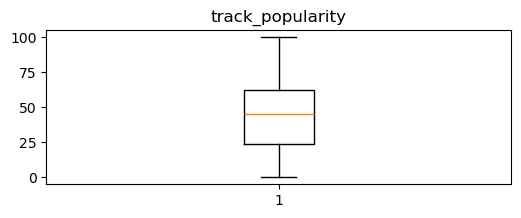

2. danceability


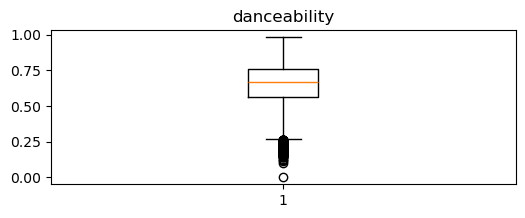

3. energy


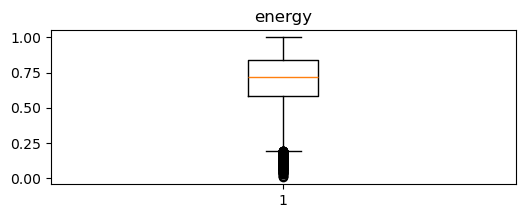

4. key


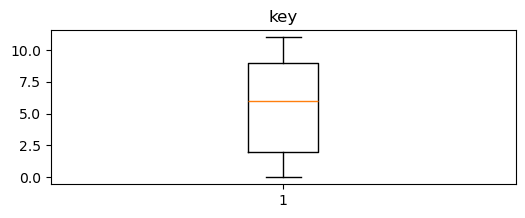

5. loudness


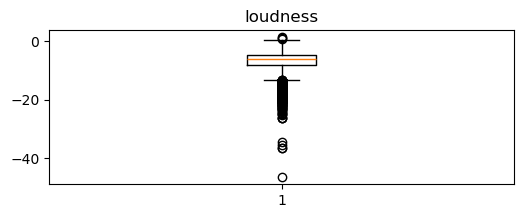

6. mode


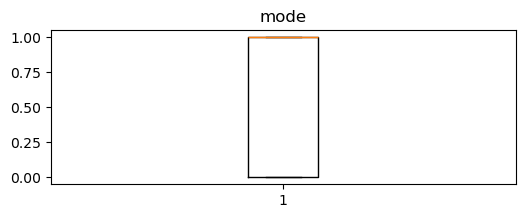

7. speechiness


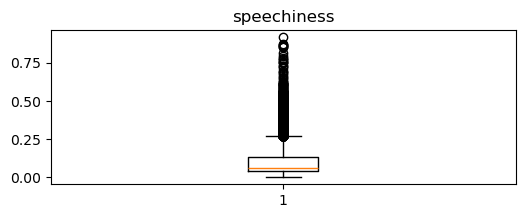

8. acousticness


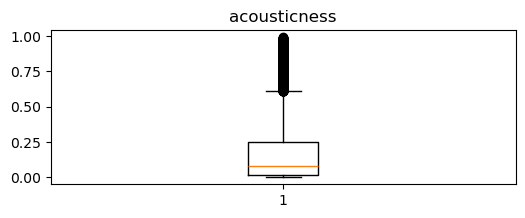

9. instrumentalness


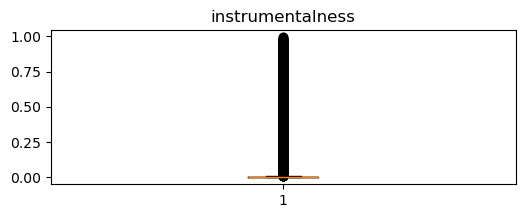

10. liveness


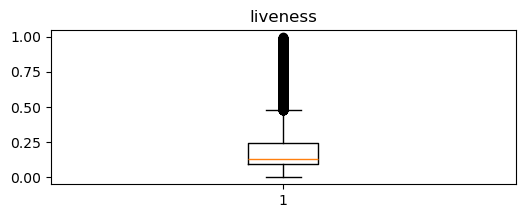

11. valence


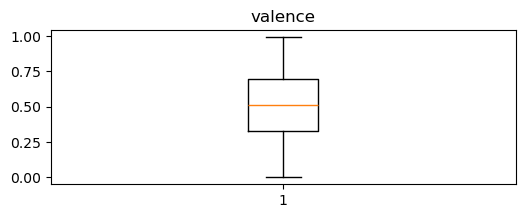

12. tempo


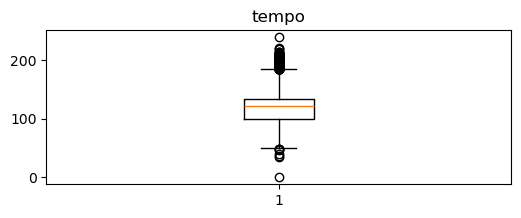

13. duration_ms


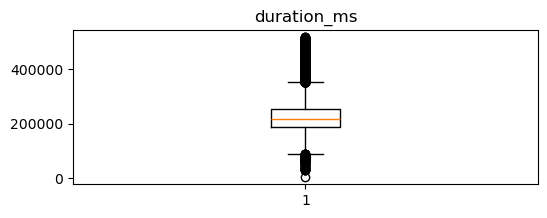

Are there any outliers?  yes
Should I mark them for removal?  no



Distribution of Target: track_popularity


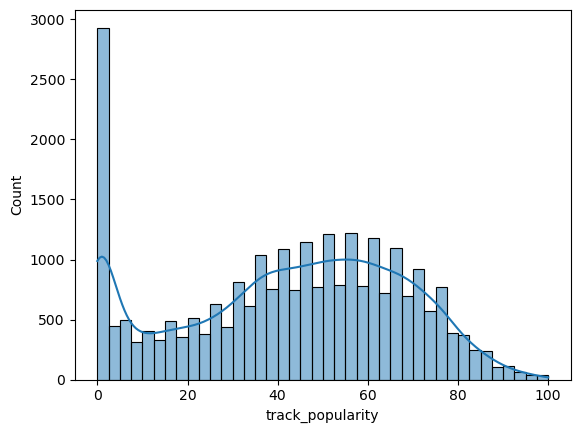


Pairplots (Batched)


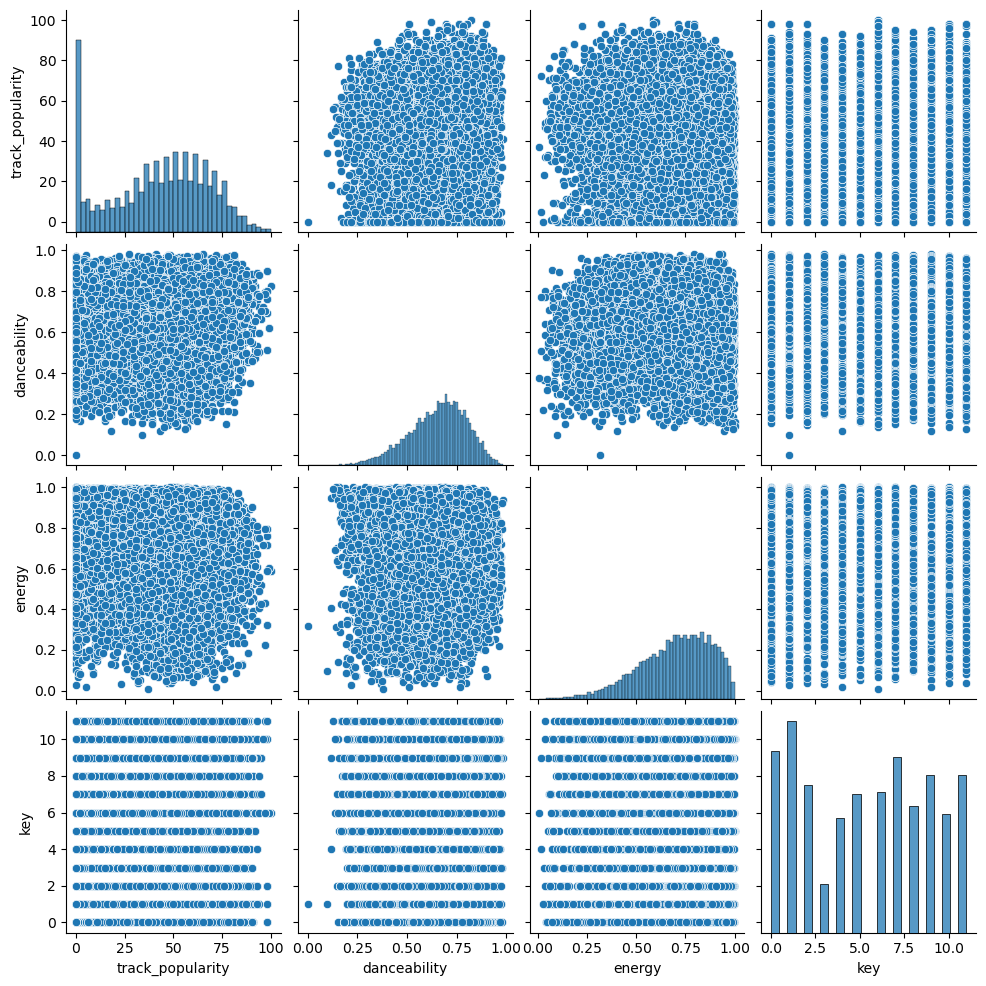

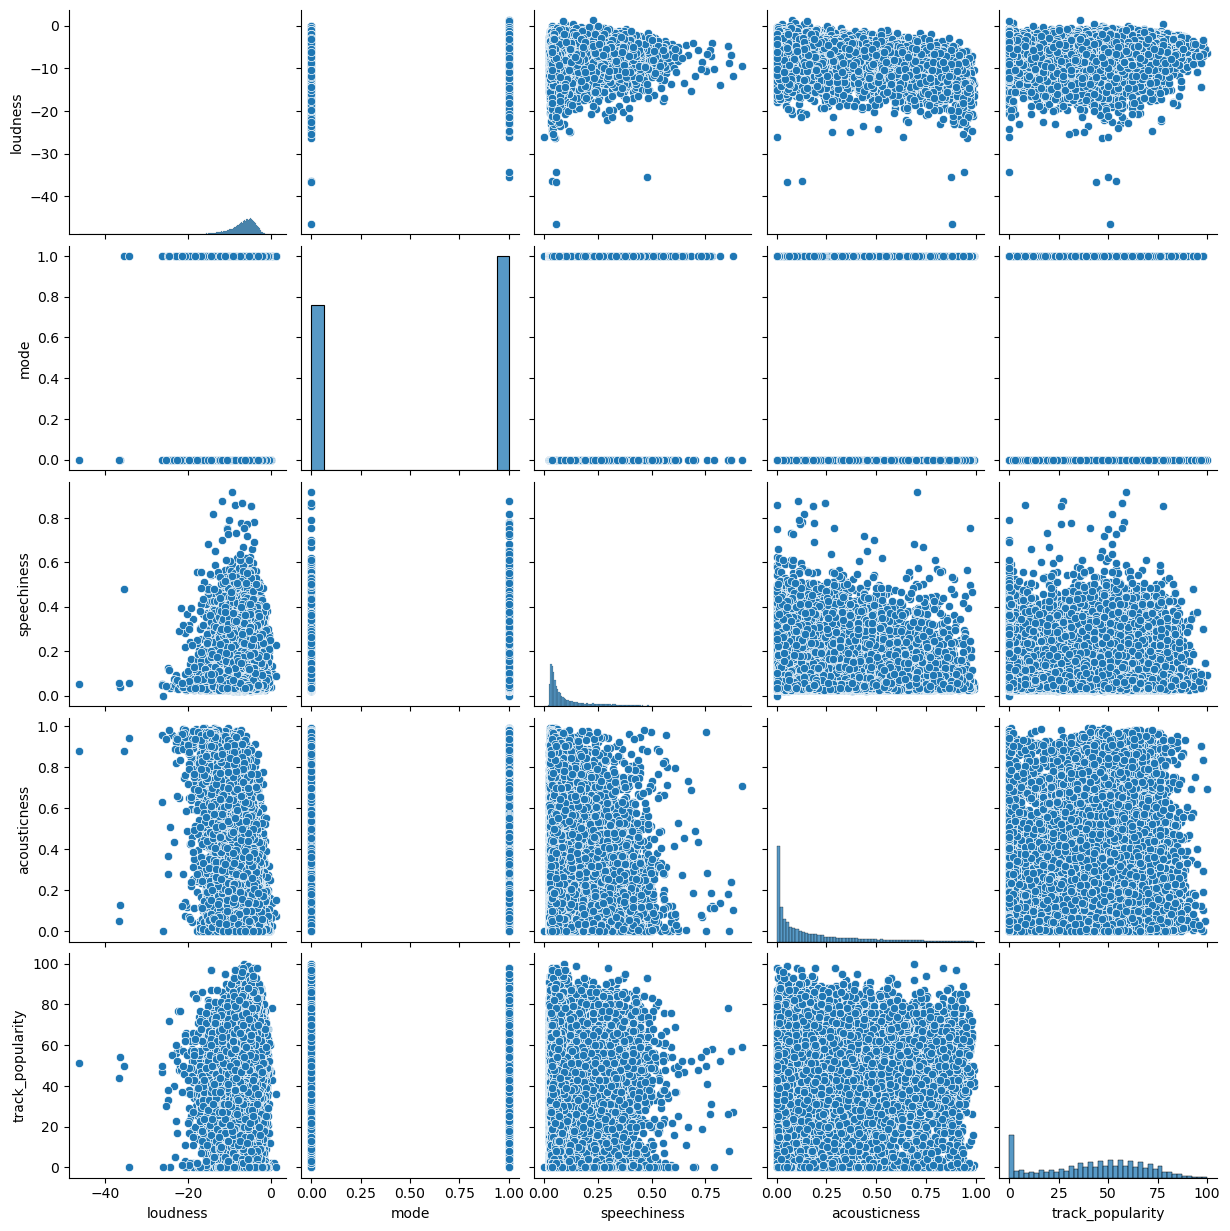

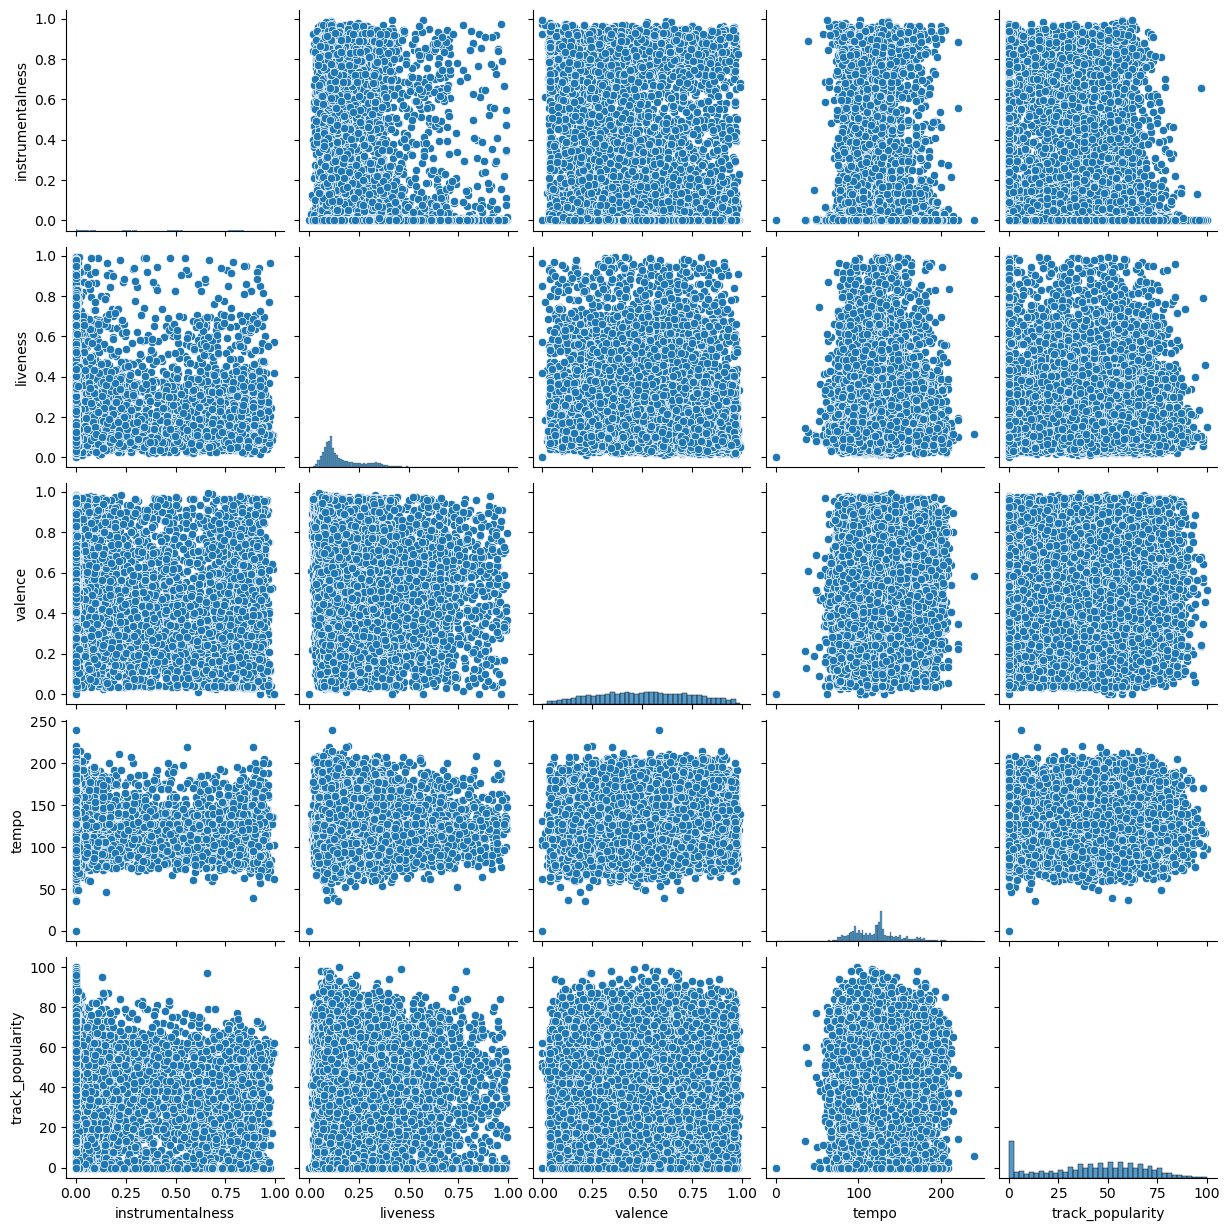

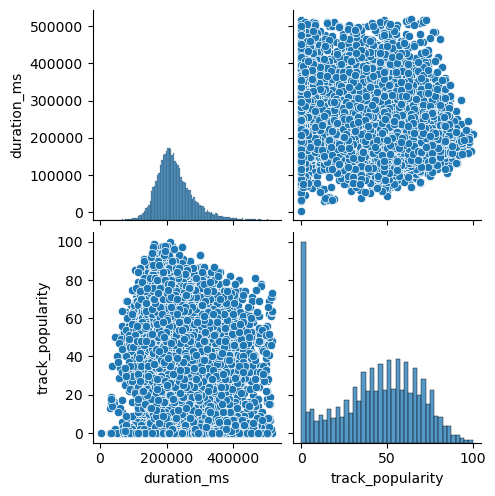

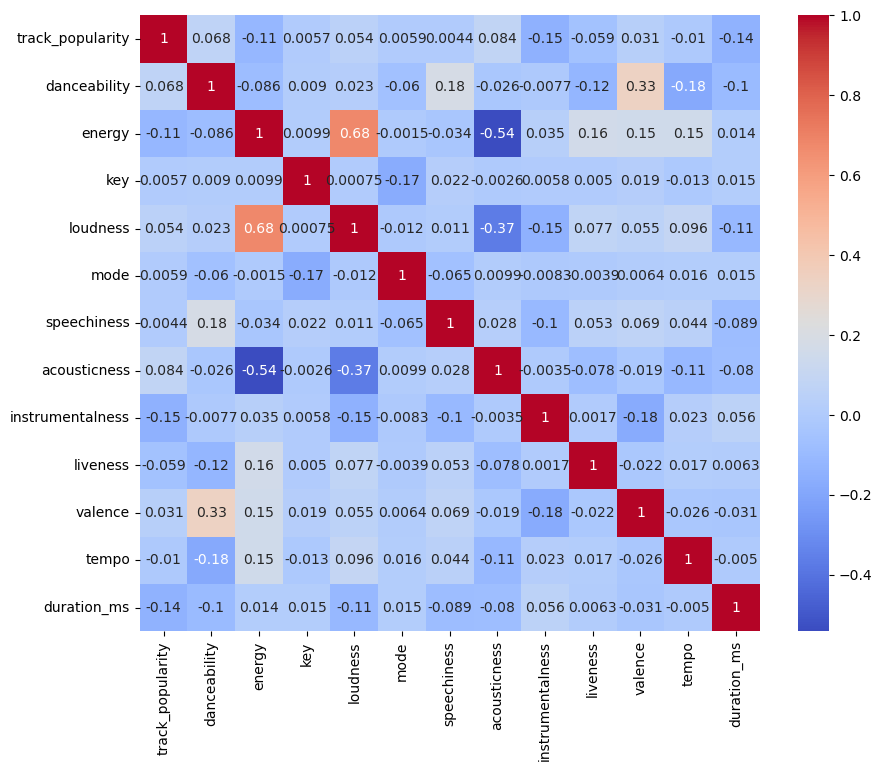

In [5]:
df = pd.read_csv("songs_train.csv", index_col=0)
preprocessing = Preprocessing(df, 'track_popularity')
preprocessing.exploratory_data_analysis()

In [6]:
preprocessing.data_cleaning()

Data Cleaing




Duplicates Section
No Duplicates Found.


Missing Values Section:

Missing Values Found:
track_name          4
track_artist        4
track_album_name    4
dtype: int64
No numerical dtype is missing

Categorical cols with missing values: ['track_name', 'track_artist', 'track_album_name']

--- Available Strategies for CATEGORICAL ---
0: Drop Rows
1: Most Frequent (Mode)
2: Placeholder (e.g., "Missing")
3: Forward Fill
4: Backward Fill


Select a number:  1


Applying strategy 1 to track_name...
Applying strategy 1 to track_artist...
Applying strategy 1 to track_album_name...
Missing values = self.df.isna.sum().sum()


Outliers Section


Do you want to remove the Outliers?  no



Outliers Kept

--- Categorical Encoding ---
Categorical columns found: ['track_id', 'track_name', 'track_artist', 'track_album_id', 'track_album_name', 'track_album_release_date', 'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre']


...

Select encoding method (number):  1


Encoding playlist_genre using One Hot Encoding...

For column 'playlist_subgenre':

--- Encoding Options ---
1: One Hot Encoding
2: Label Encoding
3: Ordinal Encoding (Auto)
4: Target Guided Encoding (Mean Encoding)


Select encoding method (number):  1


Encoding playlist_subgenre using One Hot Encoding...

Data Cleaning Complete. Encoding Finished.


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,danceability,...,playlist_subgenre_new jack swing,playlist_subgenre_permanent wave,playlist_subgenre_pop edm,playlist_subgenre_post-teen pop,playlist_subgenre_progressive electro house,playlist_subgenre_reggaeton,playlist_subgenre_southern hip hop,playlist_subgenre_trap,playlist_subgenre_tropical,playlist_subgenre_urban contemporary
id,,,,,,,,,,,,,,,,,,,,,
0,22972,8824,8.375000,0,0.000000,7487,2896,29.0,123,0.611,...,0,0,1,0,0,0,0,0,0,0
1,5435,8163,41.428571,70,64.250000,1821,3263,19.0,308,0.897,...,0,0,0,0,0,0,1,0,0,0
2,12133,2904,39.000000,39,39.000000,2671,63,63.0,285,0.748,...,0,0,1,0,0,0,0,0,0,0
3,7727,2428,78.000000,78,78.000000,2290,1233,388.0,162,0.867,...,0,0,0,0,0,0,0,1,0,0
4,18490,16027,67.000000,67,67.000000,13479,3080,300.0,188,0.669,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26261,956,783,55.625000,70,70.000000,862,1246,131.0,460,0.676,...,0,0,0,0,0,0,0,0,0,0
26262,18920,11529,60.130435,73,69.111111,6239,2627,388.0,162,0.792,...,0,0,0,0,0,0,0,1,0,0
26263,10979,7567,32.178571,50,50.000000,6537,126,391.0,311,0.613,...,0,0,0,0,1,0,0,0,0,0


In [9]:
# Final Check After Cleaning
print("--- Final Check After Cleaning ---")
print(f"Data Shape: {preprocessing.df.shape}")
print(f"Remaining Missing Values: {preprocessing.df.isna().sum().sum()}")
print(f"Remaining Duplicates: {preprocessing.df.duplicated().sum()}")
print(f"Remaining Categorical Columns: {preprocessing.df.select_dtypes(include=['object']).columns.tolist()}")
preprocessing.df.head()

--- Final Check After Cleaning ---
Data Shape: (26266, 49)
Remaining Missing Values: 0
Remaining Duplicates: 0
Remaining Categorical Columns: []


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,danceability,...,playlist_subgenre_new jack swing,playlist_subgenre_permanent wave,playlist_subgenre_pop edm,playlist_subgenre_post-teen pop,playlist_subgenre_progressive electro house,playlist_subgenre_reggaeton,playlist_subgenre_southern hip hop,playlist_subgenre_trap,playlist_subgenre_tropical,playlist_subgenre_urban contemporary
id,,,,,,,,,,,,,,,,,,,,,
0,22972,8824,8.375000,0,0.00,7487,2896,29.0,123,0.611,...,0,0,1,0,0,0,0,0,0,0
1,5435,8163,41.428571,70,64.25,1821,3263,19.0,308,0.897,...,0,0,0,0,0,0,1,0,0,0
2,12133,2904,39.000000,39,39.00,2671,63,63.0,285,0.748,...,0,0,1,0,0,0,0,0,0,0
3,7727,2428,78.000000,78,78.00,2290,1233,388.0,162,0.867,...,0,0,0,0,0,0,0,1,0,0
4,18490,16027,67.000000,67,67.00,13479,3080,300.0,188,0.669,...,0,0,0,0,0,0,0,0,1,0


In [10]:
# Save the cleaned and encoded data
os.makedirs("Data", exist_ok=True)
preprocessing.df.to_csv("Data/train_processed.csv", index=False)
print("Saved 'Data/train_processed.csv'")

Saved 'Data/train_processed.csv'
